# Exploratory Data Analysis (EDA)

## Objective:
- Understand patterns in the dataset
- Analyze relationships between variables
- Visualize distributions and correlations
- Generate insights for data mining tasks

Dataset Shape: (982, 5)

Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Statistical Summary:
         CustomerID      Gender         Age  Annual Income (k$)  \
count   982.000000  982.000000  982.000000          982.000000   
mean   1500.304481    0.479633   38.958248            0.327860   
std     288.698083    0.499840   13.417748            0.221990   
min    1000.000000    0.000000   18.000000            0.000000   
25%    1251.250000    0.000000   30.000000            0.155887   
50%    1499.500000    0.000000   36.000000            0.264524   
75%    1750.750000    1.000000   44.000000            0.499419   
max    1999.000000    1.000000   80.000000            1.000000   

       Spending Score (1-100)  
count              982.000000  
mean                 0.457185  
std                  0.221115  
min                  0.000000  
25%                  0.329670  
50%                  0.505495  
75%        

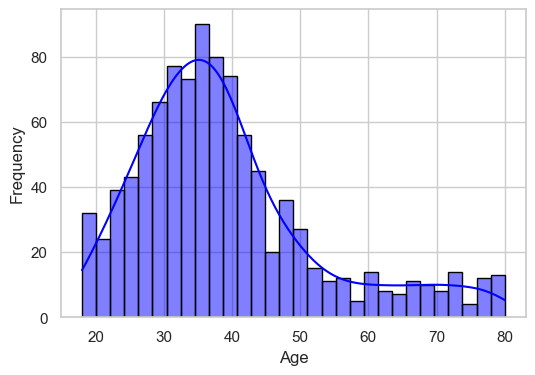

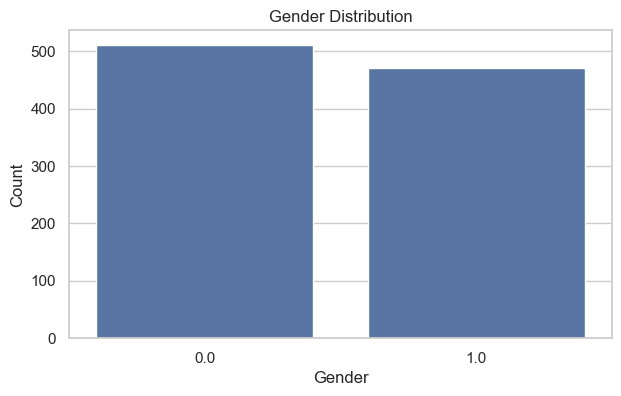

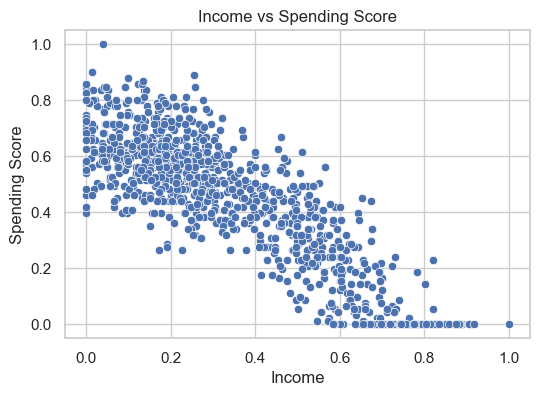

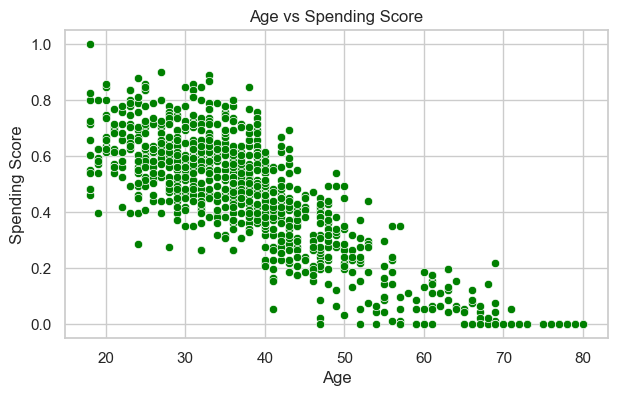

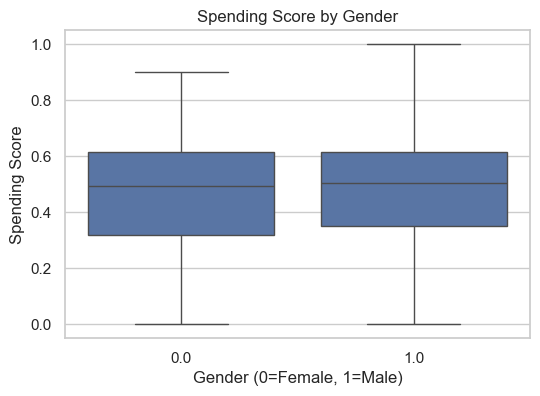

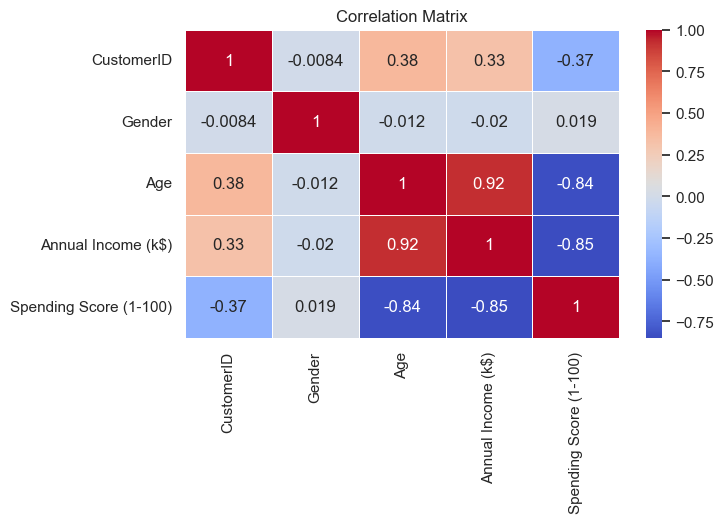

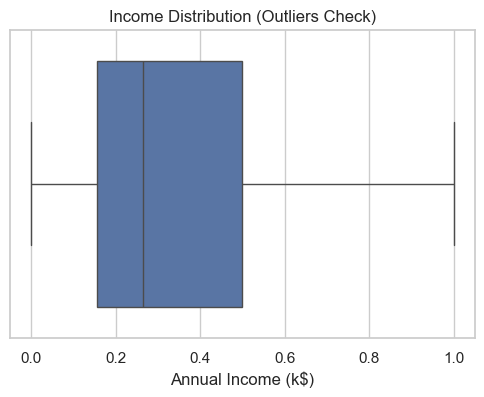

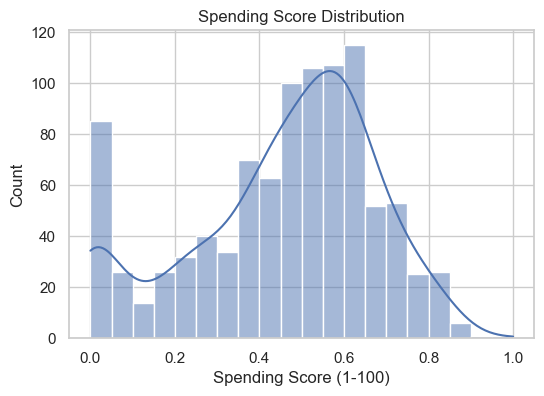


EDA Completed Successfully ✅


In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visuals
sns.set_theme(style="whitegrid")

# Load processed dataset
df = pd.read_csv('../data/processed/clean_data.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nStatistical Summary:\n", df.describe())

# -------------------------------
# AGE DISTRIBUTION
# -------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True, color='blue', edgecolor='black')
    # bins=30 → more detailed buckets
    # color='blue' → change bar color
    # edgecolor='black' → add borders to barsplt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig('../outputs/plots/age_distribution.png')
plt.show()

# -------------------------------
# GENDER DISTRIBUTION
# -------------------------------
plt.figure(figsize=(7,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.savefig('../outputs/plots/gender_distribution.png')
plt.show()

# -------------------------------
# INCOME VS SPENDING
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.savefig('../outputs/plots/income_vs_spending.png')
plt.show()

# -------------------------------
# AGE VS SPENDING
# -------------------------------
plt.figure(figsize=(7,4))
sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df,
    color='green'
)
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.savefig('../outputs/plots/age_vs_spending.png')
plt.show()


# Gender vs Spending Score
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title("Spending Score by Gender")
plt.xlabel("Gender (0=Female, 1=Male)")
plt.ylabel("Spending Score")
plt.savefig('../outputs/plots/gender_vs_spending.png')
plt.show()

# -------------------------------
# CORRELATION MATRIX (OVERALL)
# -------------------------------
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix (Overall)")
plt.savefig('../outputs/plots/correlation_matrix.png')
plt.show()

# -------------------------------
# CORRELATION MATRIX BY GENDER
# -------------------------------
# Separate data by gender
female_df = df[df['Gender'] == 0]
male_df = df[df['Gender'] == 1]

# Calculate correlations for each gender
female_corr = female_df.select_dtypes(include=['number']).corr()
male_corr = male_df.select_dtypes(include=['number']).corr()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(female_corr, annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title("Correlation Matrix (Female - Gender=0)")

sns.heatmap(male_corr, annot=True, cmap='coolwarm', linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title("Correlation Matrix (Male - Gender=1)")

plt.tight_layout()
plt.savefig('../outputs/plots/correlation_matrix_by_gender.png')
plt.show()

# Print summary
print("\nFemale Correlation with Spending Score:")
print(female_corr['Spending Score (1-100)'].sort_values(ascending=False))
print("\nMale Correlation with Spending Score:")
print(male_corr['Spending Score (1-100)'].sort_values(ascending=False))

# -------------------------------
# OUTLIER DETECTION (BOXPLOT)
# -------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Annual Income (k$)'])
plt.title("Income Distribution (Outliers Check)")
plt.savefig('../outputs/plots/income_boxplot.png')
plt.show()

# -------------------------------
# SPENDING SCORE DISTRIBUTION
# -------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.savefig('../outputs/plots/spending_distribution.png')
plt.show()

print("\nEDA Completed Successfully ✅")


## Conclusion

- Majority of customers belong to middle age groups
- Spending behavior varies even for similar income levels
- No strong linear correlation between income and spending
- Dataset is suitable for clustering and classification

EDA helps us understand patterns before applying data mining techniques.